# KPI Calculations
**Course:** Data Analysis and Indicators  
**Author:** Alan Jesús Hernández Soto
**Date:** Febraury 2026

## Objective
Estimate Cost Acquisition Cost (CAC) and the Life Time Value (LTV) of a fake start-up with real data and conclude how this KPI's affects the strategic decisions of business.

## Datasets
- **Source** Class Material
- **Files** customer_ids.csv, purchases.csv, marketing_expenses.csv

## Analysis

### 1. Data Loading and Exploration

In [1]:
import pandas as pd

customers_ids = pd.read_csv('customer_ids.csv', parse_dates=['join_date'])
purchases = pd.read_csv('purchases.csv')
marketing_expenses = pd.read_csv('marketing_expenses.csv')

customers_ids.head()

,customer_id,join_date
0,1000,2020-05-01
1,1001,2019-03-01
2,1002,2018-08-01
3,1003,2019-09-01
4,1004,2019-07-01


In [2]:
purchases.head()

,customer_id,purchase_date,purchase_amount
0,1000,2020-12,380.786751
1,1001,2021-01,137.592776
2,1001,2020-05,331.312056
3,1001,2019-04,114.376910
4,1002,2020-05,150.824205


In [3]:
marketing_expenses.head()

,month,marketing_expense
0,2018-01,5524.693974
1,2018-02,7818.313887
2,2018-03,7096.517853
3,2018-04,4557.292041
4,2018-05,5372.740000


In [4]:
customers_ids.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  300 non-null    int64         
 1   join_date    300 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 4.8 KB


In [5]:
purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1544 entries, 0 to 1543
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      1544 non-null   int64  
 1   purchase_date    1544 non-null   object 
 2   purchase_amount  1544 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 36.3+ KB


In [6]:
marketing_expenses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   month              36 non-null     object 
 1   marketing_expense  36 non-null     float64
dtypes: float64(1), object(1)
memory usage: 708.0+ bytes


### Exploratory Analysis

In [7]:
customer_purchases = purchases.merge(customers_ids, on='customer_id', how='inner')
customer_purchases.head()

,customer_id,purchase_date,purchase_amount,join_date
0,1000,2020-12,380.786751,2020-05-01
1,1001,2021-01,137.592776,2019-03-01
2,1001,2020-05,331.312056,2019-03-01
3,1001,2019-04,114.376910,2019-03-01
4,1002,2020-05,150.824205,2018-08-01


In [8]:
def calcular_cac(marketing_expense, num_customers):
    """Calcula el Costo de Adquisición de Clientes."""
    return marketing_expense / num_customers

# Uso de la función
cac = calcular_cac(5000, 100)
print(f"El CAC es: {cac}")

El CAC es: 50.0


### KPI Calculation

#### Customer Acquisition Cost

In [9]:
new_customers = clientes.groupby('join_date').count().rename(columns={'customer_id': 'new_customers'})

NameError: name 'clientes' is not defined

In [ ]:
new_customers_per_cohort = new_customers.reset_index()
new_customers_per_cohort

,join_date,new_customers
0,2018-01-01,8
1,2018-02-01,13
2,2018-03-01,11
3,2018-04-01,7
4,2018-05-01,5
5,2018-06-01,7
6,2018-07-01,9
7,2018-08-01,10
8,2018-09-01,9
9,2018-10-01,1


In [ ]:
marketing_expenses.head(2)

,month,marketing_expense
0,2018-01,5524.693974
1,2018-02,7818.313887


In [ ]:
marketing_expenses.rename(columns={'month': 'join_date'}, inplace=True)
marketing_expenses["join_date"] = pd.to_datetime(marketing_expenses['join_date'])
marketing_expenses

,join_date,marketing_expense
0,2018-01-01,5524.693974
1,2018-02-01,7818.313887
2,2018-03-01,7096.517853
3,2018-04-01,4557.292041
4,2018-05-01,5372.740000
5,2018-06-01,5788.361373
6,2018-07-01,5419.400004
7,2018-08-01,8105.396521
8,2018-09-01,8381.465359
9,2018-10-01,942.661385


In [ ]:
mkt_expenses_new_customers = marketing_expenses.merge(new_customers_per_cohort, on='join_date', how='inner')
mkt_expenses_new_customers.head()

,join_date,marketing_expense,new_customers
0,2018-01-01,5524.693974,8
1,2018-02-01,7818.313887,13
2,2018-03-01,7096.517853,11
3,2018-04-01,4557.292041,7
4,2018-05-01,5372.740000,5


In [ ]:
mkt_expenses_new_customers['cac'] = mkt_expenses_new_customers['marketing_expense'] / mkt_expenses_new_customers['new_customers']

**Visualization**

<Axes: title={'center': 'Costo de Adquisición de Clientes por Mes'}, xlabel='join_date'>

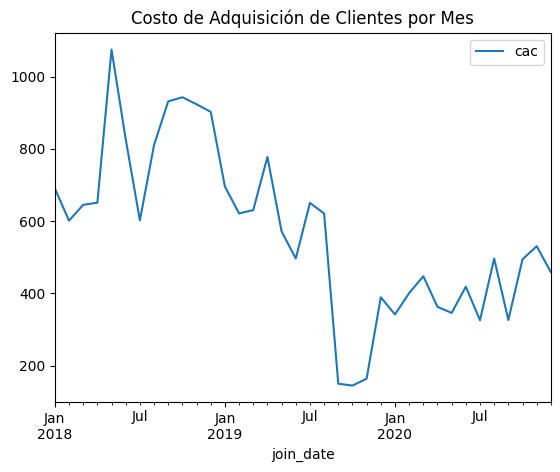

In [ ]:
mkt_expenses_new_customers.plot(x='join_date', y='cac', title='Customer Adquisition Costo over Time')

#### Life Time Value

In [ ]:
purchases.head(2)

,customer_id,purchase_date,purchase_amount
0,1000,2020-12,380.786751
1,1001,2021-01,137.592776


In [ ]:
purchases_with_cohort = customers_ids.merge(purchases, on='customer_id', how='inner')
purchases_with_cohort.head(2)
purchases_with_cohort['purchase_date'] = pd.to_datetime(purchases_with_cohort['purchase_date'])
purchases_with_cohort

,customer_id,join_date,purchase_date,purchase_amount
0,1000,2020-05-01,2020-12-01,380.786751
1,1001,2019-03-01,2021-01-01,137.592776
2,1001,2019-03-01,2020-05-01,331.312056
3,1001,2019-03-01,2019-04-01,114.376910
4,1002,2018-08-01,2020-05-01,150.824205
...,...,...,...,...
1539,1299,2019-08-01,2020-10-01,181.053054
1540,1299,2019-08-01,2021-05-01,335.034348
1541,1299,2019-08-01,2021-02-01,380.455838
1542,1299,2019-08-01,2020-11-01,372.044754


In [ ]:
max_date=purchases_with_cohort['purchase_date'].max()
max_date

Timestamp('2022-11-01 00:00:00')

In [ ]:
purchases_with_cohort['tenure'] = 12*(
    purchases_with_cohort['purchase_date'].dt.year - purchases_with_cohort['join_date'].dt.year
) + (
    purchases_with_cohort['purchase_date'].dt.month - purchases_with_cohort['join_date'].dt.month
    )

purchases_with_cohort['customer_tenure'] = 12*(
    max_date.year - purchases_with_cohort['join_date'].dt.year
) + (
    max_date.month - purchases_with_cohort['join_date'].dt.month
    )
purchases_with_cohort

,customer_id,join_date,purchase_date,purchase_amount,tenure,customer_tenure
0,1000,2020-05-01,2020-12-01,380.786751,7,30
1,1001,2019-03-01,2021-01-01,137.592776,22,44
2,1001,2019-03-01,2020-05-01,331.312056,14,44
3,1001,2019-03-01,2019-04-01,114.376910,1,44
4,1002,2018-08-01,2020-05-01,150.824205,21,51
...,...,...,...,...,...,...
1539,1299,2019-08-01,2020-10-01,181.053054,14,39
1540,1299,2019-08-01,2021-05-01,335.034348,21,39
1541,1299,2019-08-01,2021-02-01,380.455838,18,39
1542,1299,2019-08-01,2020-11-01,372.044754,15,39


In [ ]:
purchases_for_analysis = purchases_with_cohort[(purchases_with_cohort['tenure'] < 24) & (purchases_with_cohort['customer_tenure'] >= 24)]
purchases_for_analysis

,customer_id,join_date,purchase_date,purchase_amount,tenure,customer_tenure
0,1000,2020-05-01,2020-12-01,380.786751,7,30
1,1001,2019-03-01,2021-01-01,137.592776,22,44
2,1001,2019-03-01,2020-05-01,331.312056,14,44
3,1001,2019-03-01,2019-04-01,114.376910,1,44
4,1002,2018-08-01,2020-05-01,150.824205,21,51
...,...,...,...,...,...,...
1539,1299,2019-08-01,2020-10-01,181.053054,14,39
1540,1299,2019-08-01,2021-05-01,335.034348,21,39
1541,1299,2019-08-01,2021-02-01,380.455838,18,39
1542,1299,2019-08-01,2020-11-01,372.044754,15,39


In [ ]:
purchases_for_analysis

,customer_id,join_date,purchase_date,purchase_amount,tenure,customer_tenure
0,1000,2020-05-01,2020-12-01,380.786751,7,30
1,1001,2019-03-01,2021-01-01,137.592776,22,44
2,1001,2019-03-01,2020-05-01,331.312056,14,44
3,1001,2019-03-01,2019-04-01,114.376910,1,44
4,1002,2018-08-01,2020-05-01,150.824205,21,51
...,...,...,...,...,...,...
1539,1299,2019-08-01,2020-10-01,181.053054,14,39
1540,1299,2019-08-01,2021-05-01,335.034348,21,39
1541,1299,2019-08-01,2021-02-01,380.455838,18,39
1542,1299,2019-08-01,2020-11-01,372.044754,15,39


In [ ]:
customer_ltv = purchases_for_analysis.groupby('customer_id')['purchase_amount'].sum()

In [ ]:
customer_ltv

customer_id
1000     380.786751
1001     583.281742
1002    2286.811107
1003    2062.970211
1004    2773.921671
           ...     
1294     834.473192
1295    2423.196303
1296    2037.040907
1297    2257.370813
1299    1531.848670
Name: purchase_amount, Length: 292, dtype: float64

**Average LTV per cohort**

<Axes: title={'center': 'LTV Promedio por Cohort'}, xlabel='join_date'>

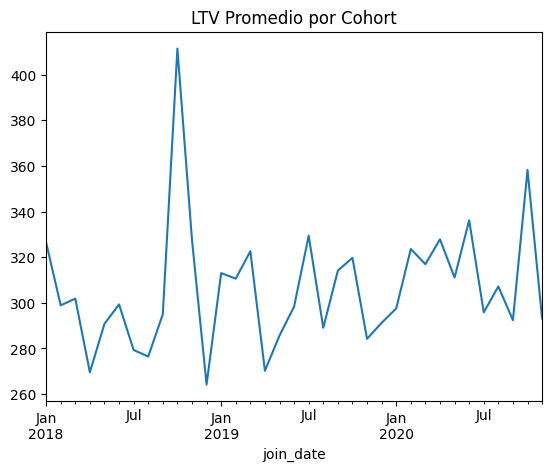

In [ ]:
cohort_ltv = purchases_for_analysis.groupby('join_date')['purchase_amount'].mean()
cohort_ltv.plot(title='Average LTV per Cohort')

**Average LTV of all customers**

In [ ]:
LTV = (purchases_for_analysis['purchase_amount'].sum())/(purchases_for_analysis['customer_id'].count()) 
print(f'Life Time Value (LTV): {LTV.round(2)} USD')
purchases_with_cohort

Valor de Vida del Cliente (LTV): 303.18 ingresos por cliente


,customer_id,join_date,purchase_date,purchase_amount,tenure,customer_tenure
0,1000,2020-05-01,2020-12-01,380.786751,7,30
1,1001,2019-03-01,2021-01-01,137.592776,22,44
2,1001,2019-03-01,2020-05-01,331.312056,14,44
3,1001,2019-03-01,2019-04-01,114.376910,1,44
4,1002,2018-08-01,2020-05-01,150.824205,21,51
...,...,...,...,...,...,...
1539,1299,2019-08-01,2020-10-01,181.053054,14,39
1540,1299,2019-08-01,2021-05-01,335.034348,21,39
1541,1299,2019-08-01,2021-02-01,380.455838,18,39
1542,1299,2019-08-01,2020-11-01,372.044754,15,39


**Best Customers**

In [ ]:
top_cohort = purchases_for_analysis.idxmax()
print(f"The cohort with the highest average LTV is: \n{top_cohort}")

El cohort con mayor LTV promedio es: 
customer_id        1539
join_date           200
purchase_date       496
purchase_amount     134
tenure               43
customer_tenure     346
dtype: int64
